In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from sklearn.cluster import HDBSCAN
from sklearn.manifold import TSNE
import numpy as np
import collections
import json


print("Loading tokenizer and model...")
xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained(
    "NX-AI/xLSTM-7b",
    config=xlstm_config,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")


Loading tokenizer and model...


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


In [2]:
print("Reading text...")
with open("big_text_prompt.txt", "r", encoding="utf-8") as f:
    prompt = f.read().strip()

inputs = tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)
bos_id = tokenizer.bos_token_id
bos_tensor = torch.tensor([[bos_id]], device=model.device, dtype=inputs.dtype)
tokens_with_bos = torch.cat([bos_tensor, inputs], dim=1)

input_tokens = [tokenizer.decode(t) for t in tokens_with_bos[0]]
seq_len = len(input_tokens)
print(f"Sequence length: {seq_len} tokens")

print("Running forward pass...")
with torch.no_grad():
    outputs = model(tokens_with_bos, output_hidden_states=True)

hidden_states = outputs.hidden_states # Tuple of 33 tensors of (1, seq_len, 4096)

results = {}

print("Running HDBSCAN and t-SNE per layer...")
# Iterate over each block's output
# hidden_states[0] is embeddings, hidden_states[1] is output of block 0, etc.
for layer_idx, h_state in enumerate(hidden_states):
    # Shape: (seq_len, 4096)
    X = h_state[0].float().cpu()
    
    # Normalize for cosine similarity equivalent using euclidean metric
    X_norm = F.normalize(X, p=2, dim=1).numpy()
    
    # We use min_cluster_size=3 since seq_len is around 170
    clusterer = HDBSCAN(min_cluster_size=3, metric='euclidean', cluster_selection_epsilon=0.1)
    labels = clusterer.fit_predict(X_norm)
    
    # Run t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X_norm)
    
    # Analyze clusters
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Group tokens by cluster
    clusters_dict = collections.defaultdict(list)
    for token, label in zip(input_tokens, labels):
        clusters_dict[int(label)].append(token.strip())
        
    layer_res = {
        "n_clusters": n_clusters,
        "n_noise_points": n_noise,
        "clusters": clusters_dict,
        "tsne_coords": X_2d.tolist(),
        "labels": [int(l) for l in labels],
        "tokens": input_tokens
    }
    results[layer_idx] = layer_res
    
    print(f"Layer {layer_idx}: {n_clusters} clusters, {n_noise} noise points")

with open("hdbscan_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
    
print("Experiment finished. Results saved to hdbscan_results.json")


Reading text...
Sequence length: 187 tokens
Running forward pass...
Running HDBSCAN and t-SNE per layer...


d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Layer 0: 12 clusters, 117 noise points


d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Layer 1: 10 clusters, 128 noise points


...

Layer 30: 3 clusters, 173 noise points


d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Layer 31: 3 clusters, 174 noise points


d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Layer 32: 3 clusters, 11 noise points
Experiment finished. Results saved to hdbscan_results.json


Loading results from hdbscan_results.json...
Generating t-SNE plots for all layers from saved results...
t-SNE clustering plots saved to hdbscan_tsne_plot.png


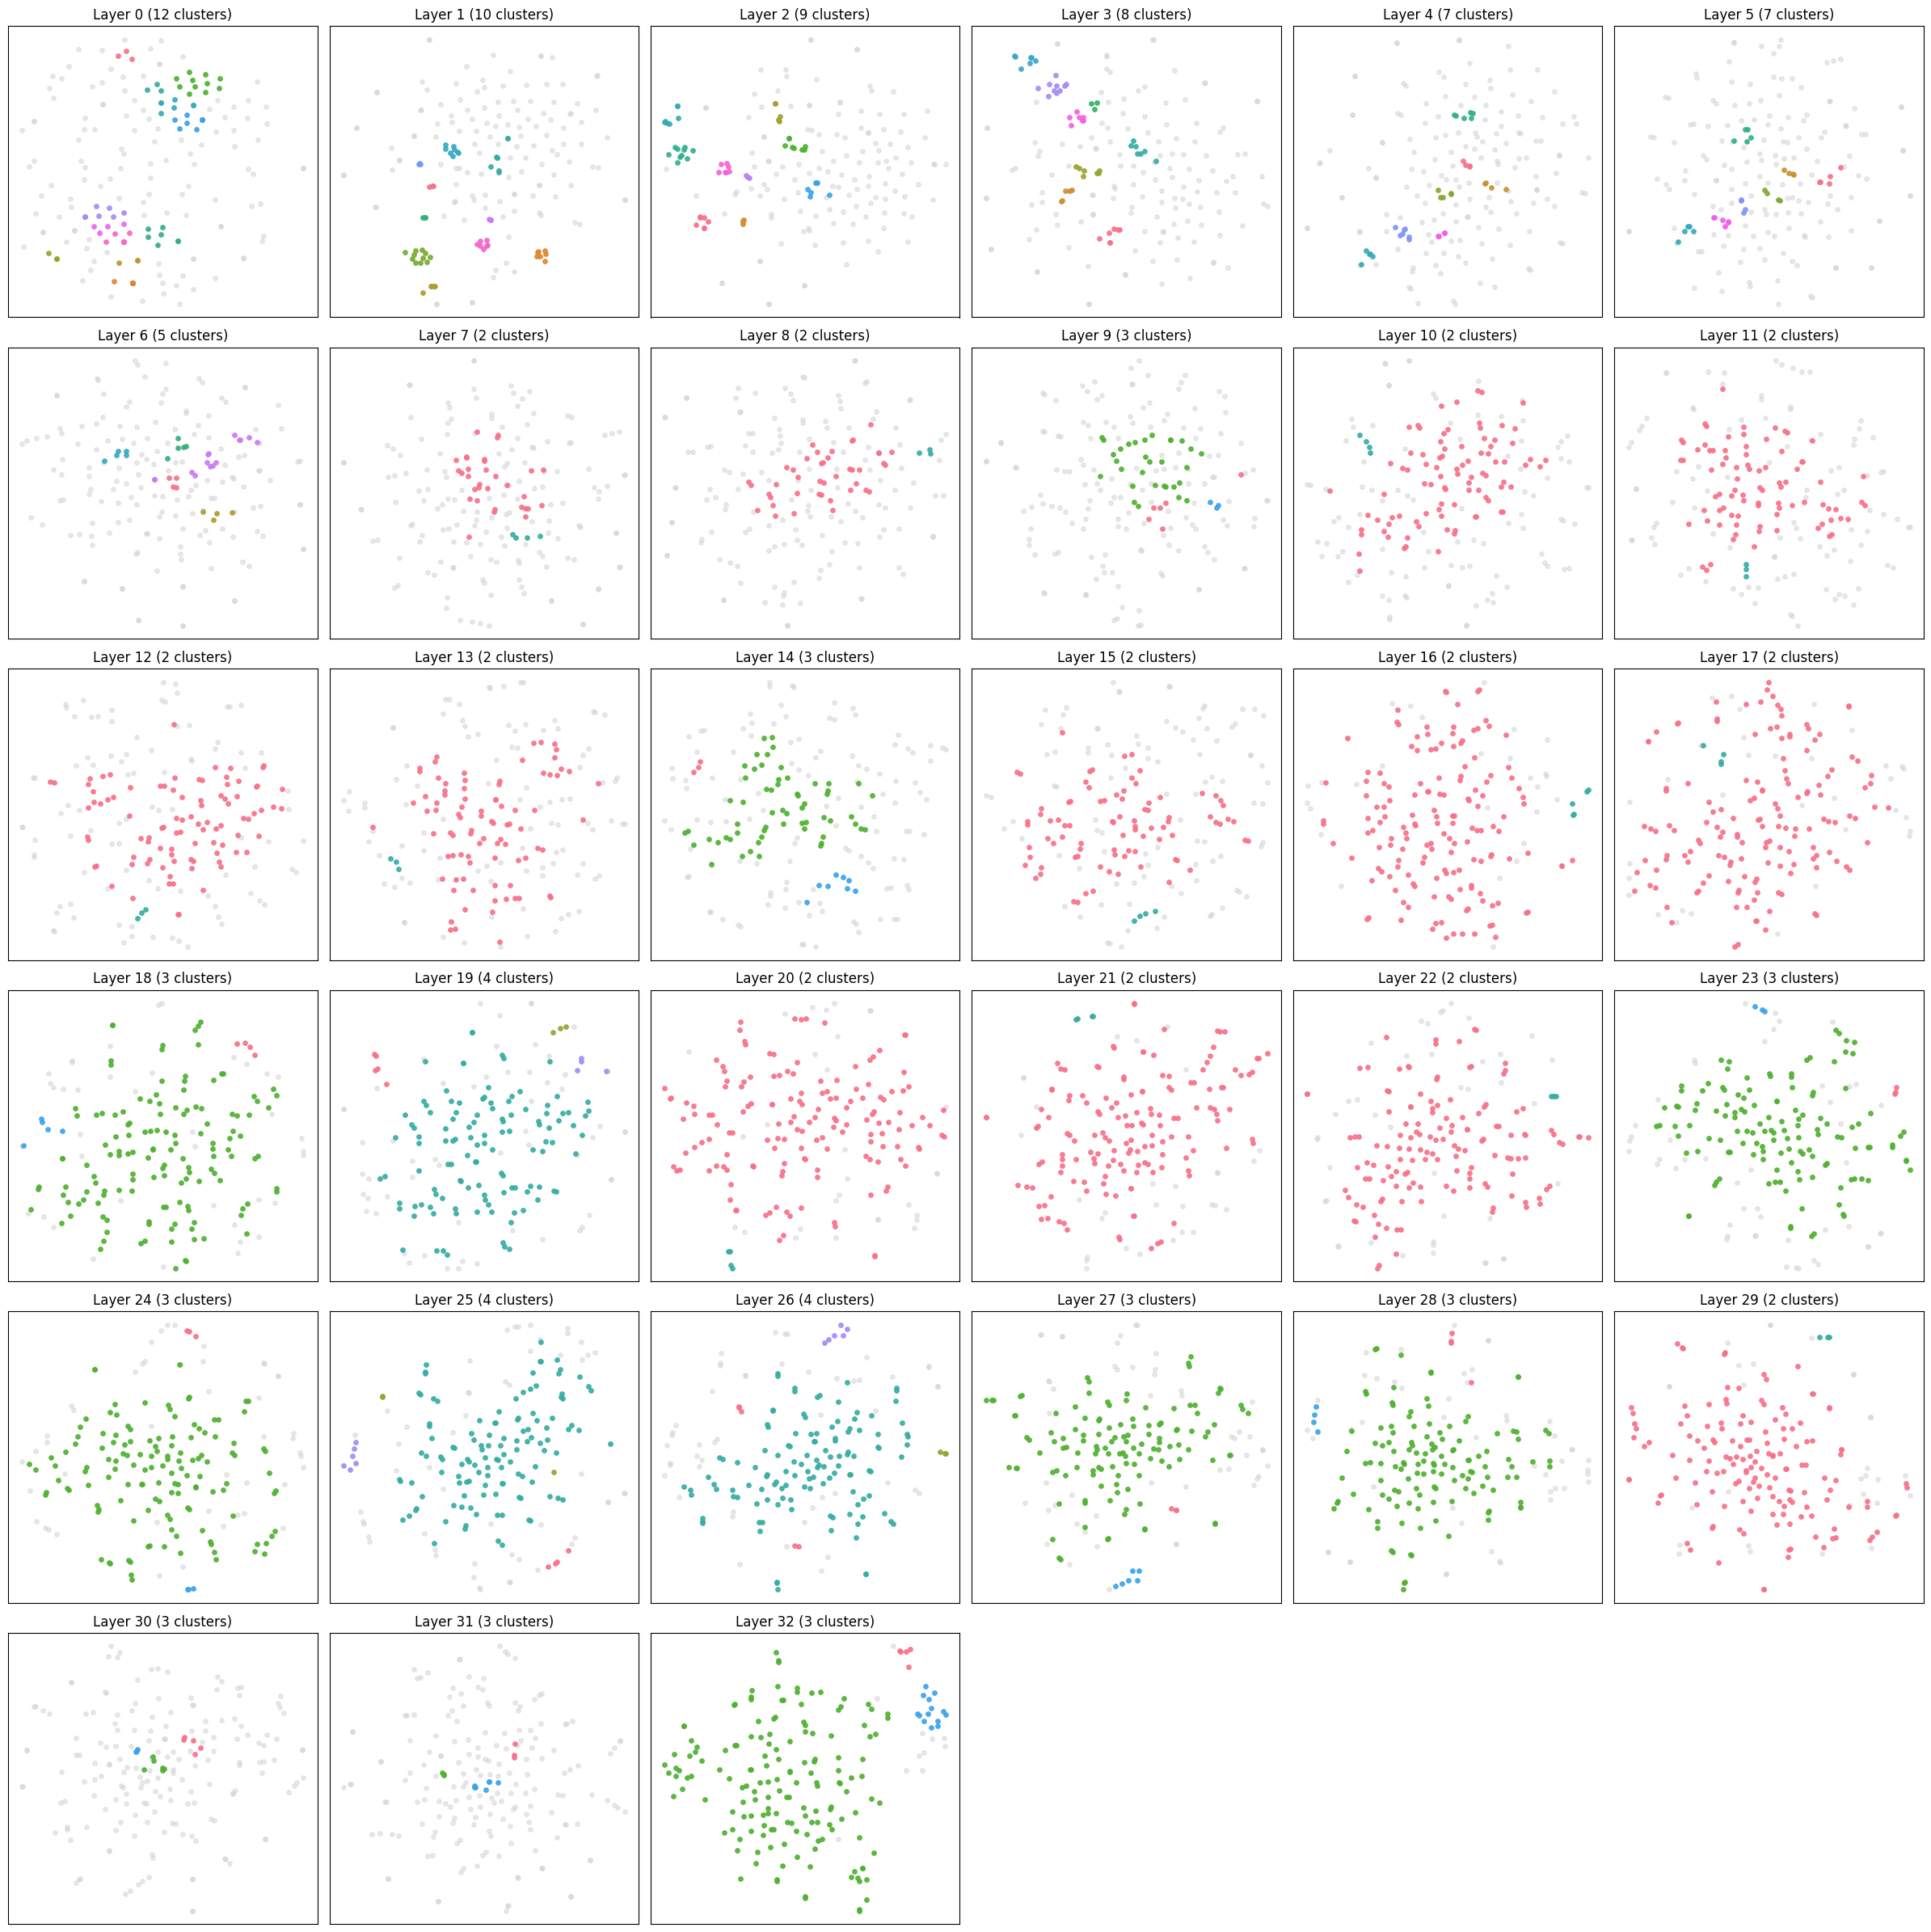

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading results from hdbscan_results.json...")
with open("hdbscan_results.json", "r", encoding="utf-8") as f:
    results = json.load(f)

print("Generating t-SNE plots for all layers from saved results...")
# Set up a 6x6 grid of subplots (for 33 layers)
fig, axes = plt.subplots(6, 6, figsize=(24, 24))
axes = axes.flatten()

# Hide the remaining 3 subplots at the end
for idx in range(33, 36):
    axes[idx].axis('off')

# Iterate over all 33 layers
for layer_idx_str in sorted(results.keys(), key=int):
    layer_idx = int(layer_idx_str)
    ax = axes[layer_idx]
    
    layer_res = results[layer_idx_str]
    X_2d = np.array(layer_res["tsne_coords"])
    labels = np.array(layer_res["labels"])
    n_clusters = layer_res["n_clusters"]
    
    # Set up color palette for clusters
    palette = sns.color_palette("husl", max(1, n_clusters))
    
    # Plot noise points (-1) in light grey
    noise_mask = (labels == -1)
    if np.any(noise_mask):
        ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c='lightgrey', s=15, alpha=0.5, label='Noise')
        
    # Plot each cluster with a different color
    unique_labels = set(labels)
    cluster_labels = sorted([l for l in unique_labels if l != -1])
    for cluster_idx, label in enumerate(cluster_labels):
        mask = (labels == label)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=palette[cluster_idx], s=15, alpha=0.9, label=f'Cluster {label}')
        
    # Formatting the subplot
    ax.set_title(f"Layer {layer_idx} ({n_clusters} clusters)", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.savefig("hdbscan_tsne_plot2.png", dpi=300, bbox_inches='tight')
print("t-SNE clustering plots saved to hdbscan_tsne_plot.png")
